# Workflow Prototype

How can we go from an image to a plan for our drone? How can we collect valuable metrics about our workflow?


**Gameplan:**
- Image Pre-processing:
    - Can we find techniques and default values suitable for this environment?
- Find regions
    - Bounding boxes (if necessary)
    - Region areas
    - Centroid points
- Post-Processing Analysis
    - Filtering by region sizes
    - Number of estimated pellets needed
    - Connect centroids with TSP


In [3]:
# Load required libraries
import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from skimage.filters import threshold_otsu
from skimage.color import rgb2lab
from scipy.ndimage import gaussian_filter, label
import rasterio
from rasterio.plot import show
from PIL import Image
from ipywidgets import interact, FloatSlider
import os
import sys
from pathlib import Path

# Add the parent directory to the Python path
# So we can find local modules e.g. "plant_search"
sys.path.append(str(Path.cwd().parent))

%matplotlib inline

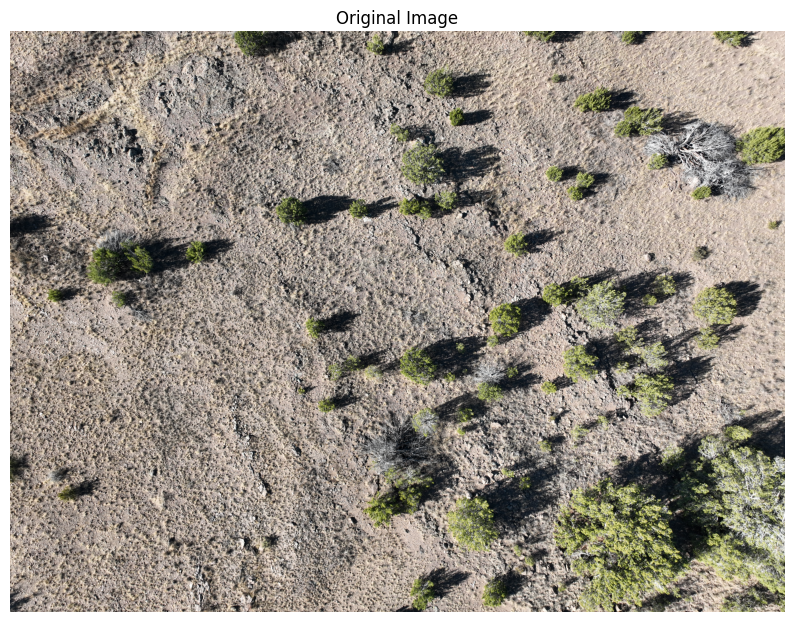

In [4]:
from plant_search.load_image import load_image, plot_image


# file_path = 'input/ESPG-4326-orthophoto.tif'
# file_path = 'input/MADRID_RGB.tif'
# file_path = '../input/aerial-trees.jpg'

# file_path = '../input/DJI_0010.JPG'
# file_path = '../input/DJI_0015.JPG'
file_path = '../input/DJI_0093.JPG'
# file_path = '../input/DJI_0119.JPG'
# file_path = '../input/Brewster-ortho.tif'

ds = 4 # downscale ratio

image = load_image(file_path)
if image is not None:
    plot_image(image, "Original Image")
    image = image[::ds, ::ds]


## Image Pre-Processing

- Vegetation Index (ExG)
- Bilateral Filtering

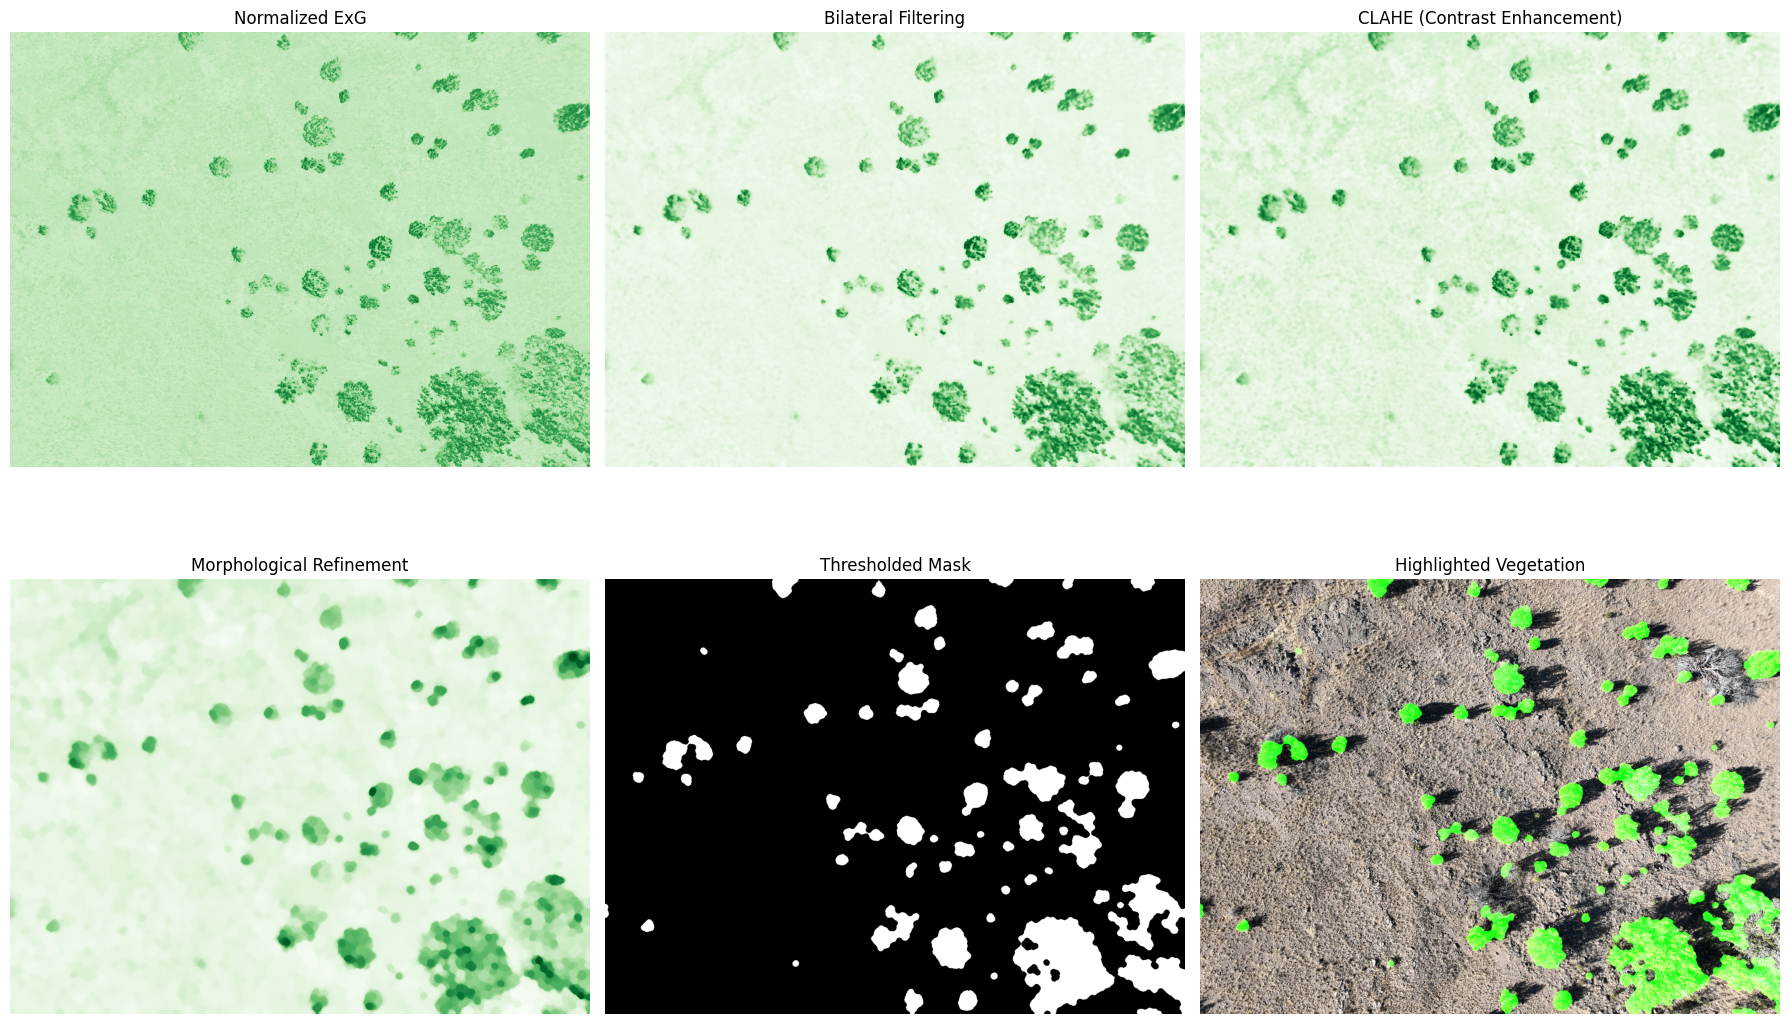

In [ ]:
from plant_search.vegetation_indices import calculate_exg, normalize_rgb
from skimage.exposure import equalize_adapthist
from skimage.morphology import opening, closing, disk


# Normalize ExG to the range [0, 255] for OpenCV compatibility
exg = calculate_exg(*normalize_rgb(image))
exg_normalized = (exg - np.min(exg)) / (np.max(exg) - np.min(exg))  # Normalize to [0, 1]
exg_uint8 = (exg_normalized * 255).astype(np.uint8)


# Step 1: Bilateral Filtering using OpenCV
bl_sigma_color = 50
bl_sigma_spatial = 15 # Lower number is faster

bilateral_smoothed_exg = cv2.bilateralFilter(
    exg_uint8 , d=9, 
    sigmaColor=bl_sigma_color, 
    sigmaSpace=bl_sigma_spatial
)
bilateral_smoothed_exg = bilateral_smoothed_exg / 255.0  # Scale back to [0, 1]

# Step 2: Contrast Enhancement with CLAHE
clahe_exg = equalize_adapthist(bilateral_smoothed_exg, clip_limit=0.008)

# Step 3: Morphological Operations (Opening → Closing)
selem = disk(7)  # Structuring element
morph_exg = closing(opening(clahe_exg, selem), selem)

# Step 4: Thresholding (Otsu's method)
otsu_threshold = threshold_otsu(morph_exg)
binary_mask = morph_exg > otsu_threshold

highlighted_image = image.copy() * 255
# Enhance the mask regions with green (or any desired enhancement)
highlighted_image[binary_mask, 1] = 1.0  # Max out the green channel for mask regions


# Visualize the Pipeline
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes[0, 0].imshow(exg_normalized, cmap='Greens')
axes[0, 0].set_title("Normalized ExG")
axes[0, 0].axis("off")

axes[0, 1].imshow(bilateral_smoothed_exg, cmap='Greens')
axes[0, 1].set_title("Bilateral Filtering")
axes[0, 1].axis("off")

axes[0, 2].imshow(clahe_exg, cmap='Greens')
axes[0, 2].set_title("CLAHE (Contrast Enhancement)")
axes[0, 2].axis("off")

axes[1, 0].imshow(morph_exg, cmap='Greens')
axes[1, 0].set_title("Morphological Refinement")
axes[1, 0].axis("off")

axes[1, 1].imshow(binary_mask, cmap='gray')
axes[1, 1].set_title("Thresholded Mask")
axes[1, 1].axis("off")

# axes[1, 2].imshow(np.clip(highlighted, 0, 1))
axes[1, 2].imshow(highlighted_image * 255)
axes[1, 2].set_title("Highlighted Vegetation")
axes[1, 2].axis("off")

plt.tight_layout()
plt.show()

## Region Search
- Bounding boxes (if necessary)
- Region areas
- Centroid points

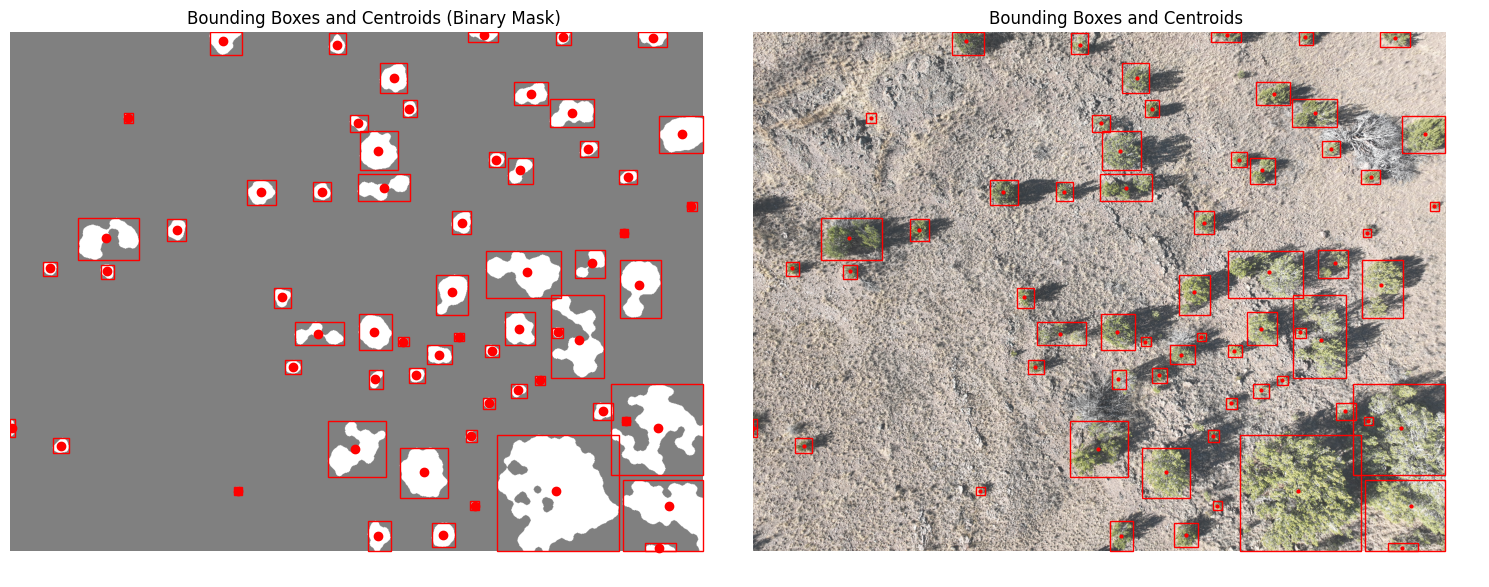

Number of regions (detected plants): 62
Number of centroids (detected plants): 62


In [ ]:

from skimage.measure import label, regionprops
from skimage.morphology import closing, disk

# Step 1: Preprocess the binary mask
selem = disk(3)  # Structuring element
cleaned_mask = closing(binary_mask, selem)  # Fill small gaps

# Step 2: Label connected components
labeled_mask = label(cleaned_mask)
regions = regionprops(labeled_mask)

# Step 3: Extract centroids and bounding boxes
centroids = []
bounding_boxes = []

for region in regions:
    # Centroid
    centroid = region.centroid  # (row, col)
    centroids.append((round(centroid[1], 2), round(centroid[0], 2)))  # Format x, y to 2 decimal places

    # Bounding box
    min_row, min_col, max_row, max_col = region.bbox
    bounding_boxes.append(((min_col, min_row), (max_col, max_row)))



fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ax1, ax2 = axes[0], axes[1]

# Step 4: Visualize results on binary mask
ax1.imshow(cleaned_mask, cmap="gray", alpha=0.5)
ax1.set_title("Bounding Boxes and Centroids (Binary Mask)")
ax1.axis("off")
for bbox, centroid in zip(bounding_boxes, centroids):
    (min_col, min_row), (max_col, max_row) = bbox # Draw bounding box
    ax1.add_patch(plt.Rectangle((min_col, min_row), max_col - min_col, max_row - min_row,
                                edgecolor="red", fill=False, linewidth=1))
    ax1.plot(centroid[0], centroid[1], "ro", markersize=2)  # Plot centroid

# Step 5: Visualize results on original image
ax2.imshow(image, alpha=0.8)
ax2.set_title("Bounding Boxes and Centroids")
ax2.axis("off")
for bbox, centroid in zip(bounding_boxes, centroids):
    (min_col, min_row), (max_col, max_row) = bbox # Draw bounding box
    ax2.add_patch(plt.Rectangle((min_col, min_row), max_col - min_col, max_row - min_row,
                                edgecolor="red", fill=False, linewidth=1))
    ax2.plot(centroid[0], centroid[1], "ro", markersize=2)  # Plot centroid

plt.tight_layout()
plt.show()


print(f"Number of regions (detected plants): {len(regions)}")
print(f"Number of centroids (detected plants): {len(centroids)}")

# Output centroids
# print("Detected Centroids:")
# for idx, centroid in enumerate(centroids):
#     print(f"Plant {idx + 1}: Centroid at (x={centroid[0]:.2f}, y={centroid[1]:.2f})")


## Post-Processing Analysis